# 🗺️ Optimization Landscapes — A Reusable 2D Test-Function Toolkit

**What this notebook does**

- Implements four canonical 2D benchmark functions used throughout the optimization literature:
  **Rosenbrock**, **Rastrigin**, **Beale**, and **Himmelblau** — exact formulas, analytic gradients
  (checked against finite differences), and known minima.
- Provides small, reusable **2D contour** and **3D surface** plotting helpers, parametrized over any of
  the four functions rather than copy-pasted per function.
- Implements minimal NumPy **GD** and **Adam** optimizers (a few lines each) and overlays their
  trajectories on every landscape.
- Highlights the *distinct* challenge each surface poses: Rosenbrock's narrow curved valley, Rastrigin's
  many local minima, Beale's flat plateau punctuated by steep edges, and Himmelblau's four equally-good
  global minima.

**How this notebook differs from the others in this repo.** Every other notebook here is single-purpose
and mostly linear top-to-bottom. This one is explicitly meant as a small **diagnostic toolkit** other
notebooks can build on (per the repo README's description of `05_visualizations/`), so the helper
functions are kept in clearly separated sections — `TestFunctions`, then `plot_landscape` /
`overlay_trajectory` — instead of being tangled into one-off cells.

**Pedagogical notes.** The GD/Adam implementations below are deliberately minimal (a handful of lines,
fixed hyperparameters passed in explicitly) for clarity and reuse — they are **not** meant to replace
`torch.optim`/production optimizer implementations.

**References**
- Rosenbrock, H. H. (1960). *An automatic method for finding the greatest or least value of a function.*
- Rastrigin, L. A. (1974). *Systems of extremal control.*
- Beale, E. M. L. (1958). *On an iterative method for finding a local minimum of a function of more than
  one variable.*
- Himmelblau, D. M. (1972). *Applied Nonlinear Programming.*
- Kingma, D. P., & Ba, J. (2015). *Adam: A Method for Stochastic Optimization.*

## 🔍 Conceptual Intuition

No single 2D test function stresses every failure mode an optimizer can run into, which is exactly why
the literature uses a small *zoo* of them side by side:

- **Rosenbrock** ("banana function") has a long, narrow, curved valley leading to its minimum. The
  gradient inside the valley is small and points almost perpendicular to the valley's direction — methods
  that don't account for this curvature (like plain GD with a fixed step size) zig-zag slowly along the
  valley floor instead of running straight down it.
- **Rastrigin** is highly multimodal — a smooth quadratic bowl with a regular grid of local minima
  superimposed on top. Any purely local, gradient-following method can get trapped in the first local
  minimum it falls into, regardless of how well-conditioned that particular basin is.
- **Beale** is nearly flat over large parts of its domain (gradients close to zero — slow progress) but
  has very steep walls near the domain edges (huge gradients — risk of instability/divergence if the step
  size isn't controlled).
- **Himmelblau** has **four distinct global minima** of exactly equal value. There's no "best" outcome
  the way there is for the other three — which minimum you reach depends entirely on which basin of
  attraction your starting point (and optimizer dynamics) falls into.

We overlay the same two optimizers — plain gradient descent and Adam — on all four surfaces so the
*qualitative* difference in what goes wrong (or doesn't) is directly comparable.

### Step-1: Imports and Environment Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import display, Markdown
try:
    import ipywidgets as widgets
    from ipywidgets import interact, FloatSlider, IntSlider, Dropdown
except Exception:
    widgets = None
    interact = None

np.random.seed(0)

## 📐 Section 1 — `TestFunctions`: Canonical 2D Benchmark Functions

Each entry below bundles the function itself, its analytic gradient, its domain (the standard plotting
box used in the literature), its known minima, and a short note on what makes it a distinct challenge.

### Step-2: Rosenbrock

In [2]:
def rosenbrock(x, y, a=1.0, b=100.0):
    return (a - x) ** 2 + b * (y - x ** 2) ** 2

def rosenbrock_grad(x, y, a=1.0, b=100.0):
    dx = -2 * (a - x) - 4 * b * x * (y - x ** 2)
    dy = 2 * b * (y - x ** 2)
    return np.array([dx, dy])

# global minimum at (a, a^2) = (1, 1), f = 0

### Step-3: Rastrigin

In [3]:
def rastrigin(x, y, A=10.0):
    return 2 * A + (x ** 2 - A * np.cos(2 * np.pi * x)) + (y ** 2 - A * np.cos(2 * np.pi * y))

def rastrigin_grad(x, y, A=10.0):
    dx = 2 * x + 2 * np.pi * A * np.sin(2 * np.pi * x)
    dy = 2 * y + 2 * np.pi * A * np.sin(2 * np.pi * y)
    return np.array([dx, dy])

# global minimum at (0, 0), f = 0; many regularly-spaced local minima elsewhere

### Step-4: Beale

In [4]:
def beale(x, y):
    c = (1.5, 2.25, 2.625)
    total = 0.0
    for i, ci in enumerate(c, start=1):
        total += (ci - x + x * y ** i) ** 2
    return total

def beale_grad(x, y):
    c = (1.5, 2.25, 2.625)
    dx = 0.0
    dy = 0.0
    for i, ci in enumerate(c, start=1):
        term = (ci - x + x * y ** i)
        dx += 2 * term * (-1 + y ** i)
        dy += 2 * term * (x * i * y ** (i - 1))
    return np.array([dx, dy])

# global minimum at (3, 0.5), f = 0

### Step-5: Himmelblau

In [5]:
def himmelblau(x, y):
    return (x ** 2 + y - 11) ** 2 + (x + y ** 2 - 7) ** 2

def himmelblau_grad(x, y):
    dx = 4 * x * (x ** 2 + y - 11) + 2 * (x + y ** 2 - 7)
    dy = 2 * (x ** 2 + y - 11) + 4 * y * (x + y ** 2 - 7)
    return np.array([dx, dy])

# four equal global minima, all f = 0:
#   (3, 2), (-2.805118, 3.131312), (-3.779310, -3.283186), (3.584428, -1.848126)

### Step-6: Registry + Sanity Checks (minima values, gradient vs. finite differences)

In [6]:
TEST_FUNCTIONS = {
    'rosenbrock': dict(
        f=rosenbrock, grad=rosenbrock_grad,
        domain=((-2.0, 2.0), (-1.0, 3.0)),
        minima=[(1.0, 1.0)],
        start=(-1.5, 2.5),
        note="narrow, curved valley -- easy direction to find, hard to traverse efficiently",
    ),
    'rastrigin': dict(
        f=rastrigin, grad=rastrigin_grad,
        domain=((-5.12, 5.12), (-5.12, 5.12)),
        minima=[(0.0, 0.0)],
        start=(3.5, 3.5),
        note="many regularly-spaced local minima -- local descent methods easily get trapped",
    ),
    'beale': dict(
        f=beale, grad=beale_grad,
        domain=((-4.5, 4.5), (-4.5, 4.5)),
        minima=[(3.0, 0.5)],
        start=(-3.5, -4.0),
        note="large flat plateau away from the minimum, punctuated by very steep corners/edges",
    ),
    'himmelblau': dict(
        f=himmelblau, grad=himmelblau_grad,
        domain=((-5.0, 5.0), (-5.0, 5.0)),
        minima=[(3.0, 2.0), (-2.805118, 3.131312), (-3.779310, -3.283186), (3.584428, -1.848126)],
        start=(-4.0, 4.0),
        note="four distinct, equally good global minima -- outcome depends on the basin of attraction",
    ),
}

# sanity check 1: each function should be (numerically) zero at its stated minima
for name, spec in TEST_FUNCTIONS.items():
    for (mx, my) in spec['minima']:
        val = spec['f'](mx, my)
        print(f"{name:12s} f{mx, my} = {val:.3g}")
        assert abs(val) < 1e-4, f"{name} minimum check failed at {(mx, my)}: f={val}"

# sanity check 2: analytic gradients match central finite differences at random points
def finite_diff_grad(f, x, y, eps=1e-6):
    dx = (f(x + eps, y) - f(x - eps, y)) / (2 * eps)
    dy = (f(x, y + eps) - f(x, y - eps)) / (2 * eps)
    return np.array([dx, dy])

rng = np.random.RandomState(1)
for name, spec in TEST_FUNCTIONS.items():
    (xlo, xhi), (ylo, yhi) = spec['domain']
    for _ in range(5):
        x, y_ = rng.uniform(xlo, xhi), rng.uniform(ylo, yhi)
        g_analytic = spec['grad'](x, y_)
        g_fd = finite_diff_grad(spec['f'], x, y_)
        relerr = np.linalg.norm(g_analytic - g_fd) / (np.linalg.norm(g_fd) + 1e-8)
        assert relerr < 1e-3, f"{name} gradient mismatch at ({x},{y_}): relerr={relerr}"
print("\nAll analytic gradients match finite differences (max rel. error < 1e-3).")

rosenbrock   f(1.0, 1.0) = 0
rastrigin    f(0.0, 0.0) = 0
beale        f(3.0, 0.5) = 0
himmelblau   f(3.0, 2.0) = 0
himmelblau   f(-2.805118, 3.131312) = 1.1e-11
himmelblau   f(-3.77931, -3.283186) = 3.8e-12
himmelblau   f(3.584428, -1.848126) = 8.89e-12

All analytic gradients match finite differences (max rel. error < 1e-3).


## 🎨 Section 2 — Reusable Plotting Helpers

`plot_landscape` and `overlay_trajectory` work with *any* entry in `TEST_FUNCTIONS` — write once, reuse
across all four surfaces (and any future function you register in the dict above).

### Step-7: `plot_landscape` (2D contour / 3D surface) and `overlay_trajectory`

In [7]:
def make_grid(domain, n=300):
    (xlo, xhi), (ylo, yhi) = domain
    xs = np.linspace(xlo, xhi, n)
    ys = np.linspace(ylo, yhi, n)
    X, Y = np.meshgrid(xs, ys)
    return X, Y

def plot_landscape(name, ax=None, kind='contour', n=300, log_levels=True, cmap='viridis'):
    spec = TEST_FUNCTIONS[name]
    X, Y = make_grid(spec['domain'], n=n)
    Z = spec['f'](X, Y)
    if kind == 'contour':
        if ax is None:
            _, ax = plt.subplots(figsize=(6, 5))
        levels = np.logspace(np.log10(max(Z.min(), 1e-3)), np.log10(Z.max() + 1), 40) if log_levels else 40
        norm = matplotlib.colors.LogNorm() if log_levels else None
        ax.contourf(X, Y, Z, levels=levels, cmap=cmap, norm=norm)
        for (mx, my) in spec['minima']:
            ax.scatter(mx, my, marker='*', c='red', s=150, edgecolors='white', zorder=5)
        ax.set_title(name)
        ax.set_xlabel('x'); ax.set_ylabel('y')
        return ax
    elif kind == 'surface':
        if ax is None:
            fig = plt.figure(figsize=(7, 6))
            ax = fig.add_subplot(111, projection='3d')
        ax.plot_surface(X, Y, Z, cmap=cmap, alpha=0.85, linewidth=0, antialiased=True)
        ax.set_title(name)
        ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('f(x,y)')
        return ax
    else:
        raise ValueError("kind must be 'contour' or 'surface'")

def overlay_trajectory(ax, path, color='k', label=None, marker_start='x', marker_end='o'):
    path = np.asarray(path)
    ax.plot(path[:, 0], path[:, 1], '-', color=color, lw=1.8, alpha=0.9, label=label)
    ax.scatter(path[0, 0], path[0, 1], marker=marker_start, c=color, s=70, zorder=6)
    ax.scatter(path[-1, 0], path[-1, 1], marker=marker_end, c=color, s=50, zorder=6)
    return ax

## 🚶 Section 3 — Minimal GD and Adam, Overlaid on Every Landscape

### Step-8: Minimal Optimizer Implementations

In [8]:
def run_gd(grad_fn, start, lr=0.001, n_iter=1000, clip=5.0):
    x = np.array(start, dtype=float)
    path = [x.copy()]
    for _ in range(n_iter):
        g = np.clip(grad_fn(x[0], x[1]), -clip, clip)
        x = x - lr * g
        path.append(x.copy())
    return np.array(path)

def run_adam(grad_fn, start, lr=0.05, beta1=0.9, beta2=0.999, eps=1e-8, n_iter=1000, clip=5.0):
    x = np.array(start, dtype=float)
    m = np.zeros_like(x); v = np.zeros_like(x)
    path = [x.copy()]
    for t in range(1, n_iter + 1):
        g = np.clip(grad_fn(x[0], x[1]), -clip, clip)
        m = beta1 * m + (1 - beta1) * g
        v = beta2 * v + (1 - beta2) * (g * g)
        m_hat = m / (1 - beta1 ** t)
        v_hat = v / (1 - beta2 ** t)
        x = x - lr * m_hat / (np.sqrt(v_hat) + eps)
        path.append(x.copy())
    return np.array(path)

# per-function hyperparameters -- each surface needs a different step size to behave sensibly
# (e.g. Beale's gradients are large near the domain edges, so GD needs both a small lr and clipping
# to avoid diverging off the plotted domain).
CONFIGS = {
    'rosenbrock': dict(gd_lr=0.0012, adam_lr=0.05, n_iter=3000, clip=5.0),
    'rastrigin':  dict(gd_lr=0.01,   adam_lr=0.08, n_iter=1000, clip=5.0),
    'beale':      dict(gd_lr=0.0005, adam_lr=0.05, n_iter=4000, clip=5.0),
    'himmelblau': dict(gd_lr=0.005,  adam_lr=0.1,  n_iter=2000, clip=5.0),
}

### Step-9: Run GD and Adam on Every Landscape

In [9]:
results = {}
for name, cfg in CONFIGS.items():
    spec = TEST_FUNCTIONS[name]
    path_gd = run_gd(spec['grad'], spec['start'], lr=cfg['gd_lr'], n_iter=cfg['n_iter'], clip=cfg['clip'])
    path_adam = run_adam(spec['grad'], spec['start'], lr=cfg['adam_lr'], n_iter=cfg['n_iter'], clip=cfg['clip'])
    results[name] = dict(path_gd=path_gd, path_adam=path_adam)

    f_gd, f_adam = spec['f'](*path_gd[-1]), spec['f'](*path_adam[-1])
    dist_gd = min(np.linalg.norm(np.array(m) - path_gd[-1]) for m in spec['minima'])
    dist_adam = min(np.linalg.norm(np.array(m) - path_adam[-1]) for m in spec['minima'])
    print(f"{name:12s} [{spec['note']}]")
    print(f"  GD:   final f={f_gd:9.4f}  dist to nearest known min={dist_gd:7.4f}  end=({path_gd[-1,0]:.3f},{path_gd[-1,1]:.3f})")
    print(f"  Adam: final f={f_adam:9.4f}  dist to nearest known min={dist_adam:7.4f}  end=({path_adam[-1,0]:.3f},{path_adam[-1,1]:.3f})")
    assert np.isfinite(path_gd).all() and np.isfinite(path_adam).all(), f"{name}: non-finite trajectory"

rosenbrock   [narrow, curved valley -- easy direction to find, hard to traverse efficiently]
  GD:   final f=   0.0371  dist to nearest known min= 0.3984  end=(0.807,0.651)
  Adam: final f=   0.0000  dist to nearest known min= 0.0005  end=(1.000,1.000)
rastrigin    [many regularly-spaced local minima -- local descent methods easily get trapped]
  GD:   final f=  18.0000  dist to nearest known min= 4.2426  end=(3.000,3.000)
  Adam: final f=  17.9092  dist to nearest known min= 4.2212  end=(2.985,2.985)
beale        [large flat plateau away from the minimum, punctuated by very steep corners/edges]
  GD:   final f=   0.0911  dist to nearest known min= 0.5697  end=(2.457,0.328)
  Adam: final f=   0.0000  dist to nearest known min= 0.0000  end=(3.000,0.500)
himmelblau   [four distinct, equally good global minima -- outcome depends on the basin of attraction]
  GD:   final f=   0.0000  dist to nearest known min= 0.0000  end=(-2.805,3.131)
  Adam: final f=   0.0000  dist to nearest known min=

**What to notice:** on **Rosenbrock**, Adam tracks the curved valley almost exactly to the minimum while
plain GD is still working its way down it after the same iteration budget. On **Rastrigin**, *both*
optimizers get trapped in a local minimum near the starting point rather than reaching the global minimum
at the origin — exactly the multimodal-trap behavior the function is designed to illustrate; a purely
local method has no way to escape without extra machinery (random restarts, simulated annealing, etc).
On **Beale**, GD makes only partial progress under the small, clipped step size the plateau+edges demand,
while Adam's per-parameter scaling reaches the minimum almost exactly. On **Himmelblau**, both optimizers
converge to the *same* one of the four equally-good minima — the one whose basin of attraction contains
the shared starting point.

### Step-10: Visualize All Four Landscapes with Overlaid Trajectories

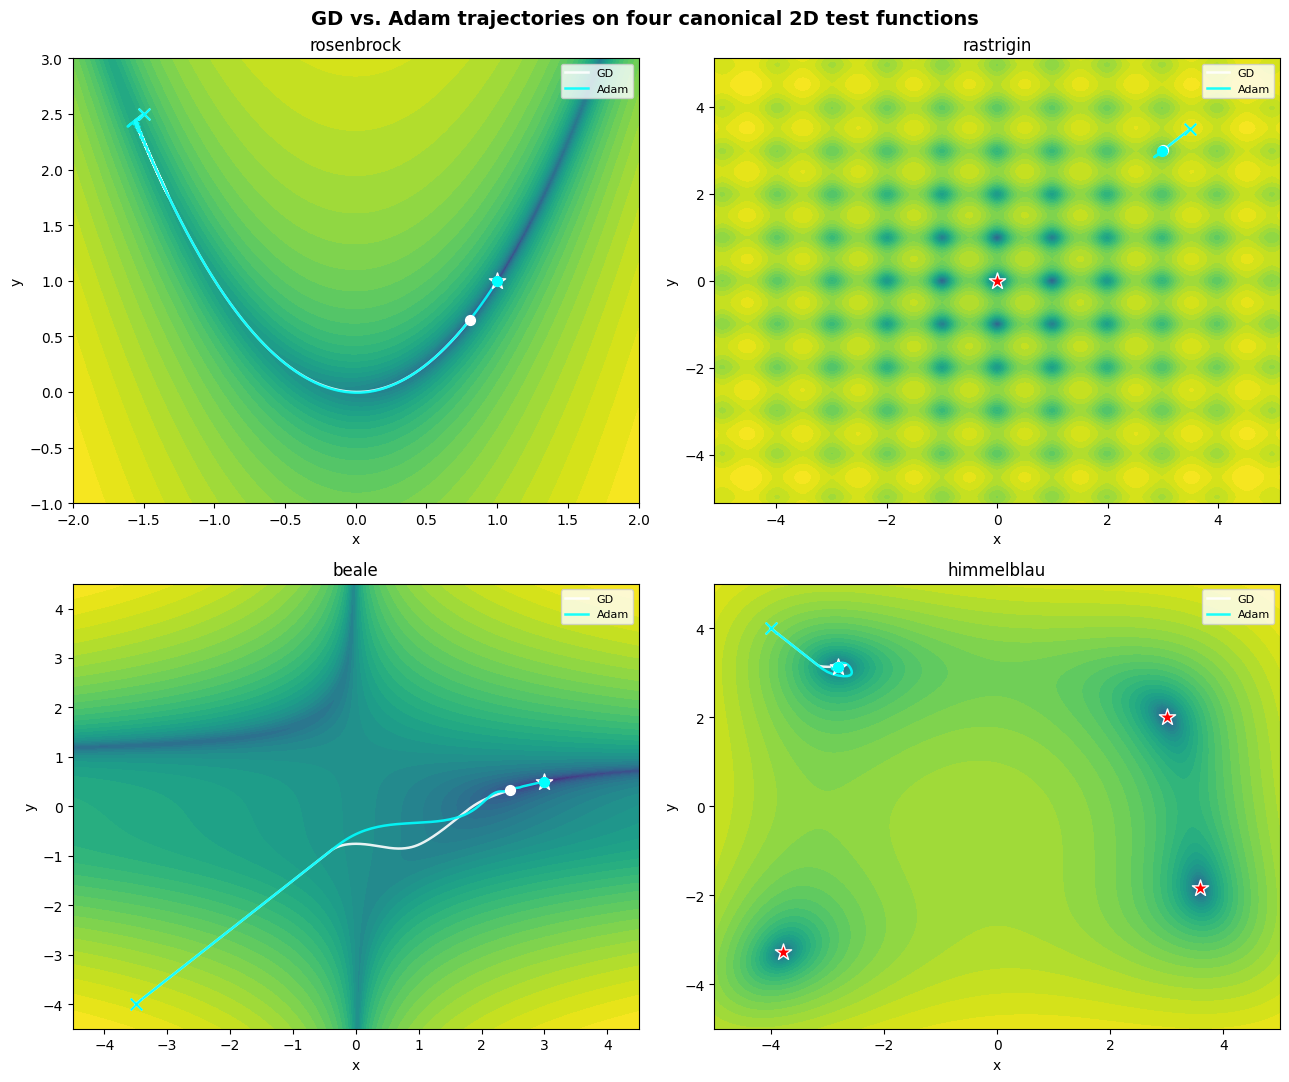

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(13, 11))
for ax, name in zip(axes.ravel(), TEST_FUNCTIONS.keys()):
    plot_landscape(name, ax=ax, kind='contour')
    overlay_trajectory(ax, results[name]['path_gd'], color='white', label='GD')
    overlay_trajectory(ax, results[name]['path_adam'], color='cyan', label='Adam')
    ax.legend(loc='upper right', fontsize=8)
plt.suptitle("GD vs. Adam trajectories on four canonical 2D test functions", fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

### Step-11: 3D Surface View (Reusing the Same Helper)

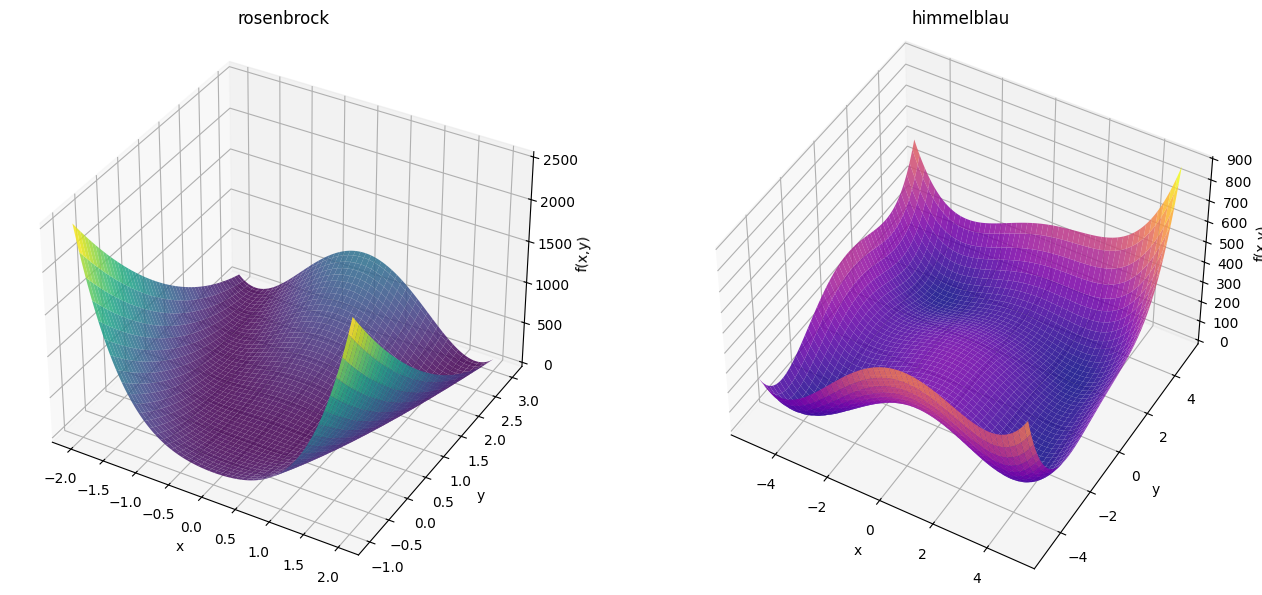

In [11]:
fig = plt.figure(figsize=(14, 6))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
plot_landscape('rosenbrock', ax=ax1, kind='surface', n=150)
ax1.view_init(elev=35, azim=-60)

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
plot_landscape('himmelblau', ax=ax2, kind='surface', n=150, cmap='plasma')
ax2.view_init(elev=45, azim=-60)
plt.tight_layout()
plt.show()

### Step-12: Interactive Exploration — Pick a Function and Optimizer Hyperparameters

In [12]:
if widgets is None:
    display(Markdown("**ipywidgets not installed — run the static cells above instead.**"))
else:
    def interactive_landscape(function=list(TEST_FUNCTIONS.keys())[0], gd_lr=0.001, adam_lr=0.05, n_iter=1500):
        spec = TEST_FUNCTIONS[function]
        path_gd = run_gd(spec['grad'], spec['start'], lr=gd_lr, n_iter=n_iter, clip=5.0)
        path_adam = run_adam(spec['grad'], spec['start'], lr=adam_lr, n_iter=n_iter, clip=5.0)

        fig, ax = plt.subplots(figsize=(7, 6))
        plot_landscape(function, ax=ax, kind='contour')
        overlay_trajectory(ax, path_gd, color='white', label='GD')
        overlay_trajectory(ax, path_adam, color='cyan', label='Adam')
        ax.legend(loc='upper right')
        ax.set_title(f"{function}  —  {spec['note']}")
        plt.tight_layout()
        plt.show()

        f_gd, f_adam = spec['f'](*path_gd[-1]), spec['f'](*path_adam[-1])
        display(Markdown(
            f"GD final f = **{f_gd:.4g}** at ({path_gd[-1,0]:.3f}, {path_gd[-1,1]:.3f})  |  "
            f"Adam final f = **{f_adam:.4g}** at ({path_adam[-1,0]:.3f}, {path_adam[-1,1]:.3f})"
        ))

    interact(
        interactive_landscape,
        function=Dropdown(options=list(TEST_FUNCTIONS.keys()), value='rosenbrock', description='function'),
        gd_lr=FloatSlider(value=0.001, min=0.0001, max=0.02, step=0.0001, description='GD lr', readout_format='.4f'),
        adam_lr=FloatSlider(value=0.05, min=0.001, max=0.3, step=0.001, description='Adam lr'),
        n_iter=IntSlider(value=1500, min=100, max=5000, step=100, description='iterations'),
    )

interactive(children=(Dropdown(description='function', options=('rosenbrock', 'rastrigin', 'beale', 'himmelbla…

## ✅ Practical Notes & Takeaways

- **A single test function is not enough to characterize an optimizer.** Rosenbrock alone tells you about
  curvature-following ability; Rastrigin alone tells you about escaping local minima; neither tells you
  anything about the other. Always sanity-check a new optimizer against a small *battery* of these
  functions, not just one.
- **Gradient clipping matters even in a toy 2D setting.** Beale's steep edges make unclipped GD diverge
  outright with a naively-large learning rate — a preview of exploding gradients in real, much
  higher-dimensional training.
- **"Convergence" is ambiguous for multimodal or multi-minimum surfaces.** On Rastrigin, low final loss
  can still mean the wrong (local) minimum. On Himmelblau, all four minima are equally "correct" — which
  one you land in is a property of initialization + optimizer dynamics, not of solution quality.
- **This module is meant to be imported/reused, not just read.** `TEST_FUNCTIONS`, `plot_landscape`, and
  `overlay_trajectory` are written so you can drop in a fifth function, or swap in a different optimizer's
  trajectory function, without touching the plotting code.

## 🧾 Summary

- We built a small, reusable **toolkit** — `TEST_FUNCTIONS` (Rosenbrock, Rastrigin, Beale, Himmelblau,
  each with exact formulas, analytic gradients checked against finite differences, and documented known
  minima) plus generic `plot_landscape`/`overlay_trajectory` helpers.
- We overlaid minimal GD and Adam trajectories on all four surfaces and confirmed, numerically, that each
  function stresses a genuinely different failure mode: curvature-following (Rosenbrock), multimodality
  (Rastrigin), flat-plateau/steep-edge step-size sensitivity (Beale), and basin-of-attraction dependence
  under multiple equally-good optima (Himmelblau).
- This notebook is intended as infrastructure other notebooks in this repo can build on directly, per the
  `05_visualizations/` module description in the README.

**References**
- Rosenbrock, H. H. (1960). *An automatic method for finding the greatest or least value of a function.*
- Rastrigin, L. A. (1974). *Systems of extremal control.*
- Beale, E. M. L. (1958). *On an iterative method for finding a local minimum of a function of more than
  one variable.*
- Himmelblau, D. M. (1972). *Applied Nonlinear Programming.*
- Kingma, D. P., & Ba, J. (2015). *Adam: A Method for Stochastic Optimization.*